# Brain Tumor Classification using EfficientNetB0
End-to-end pipeline: EDA → Preprocessing → Training → Fine-tuning → Evaluation → TFLite Conversion

**Dataset:** T1-weighted MRI Images (Grayscale)
**Classes:** glioma, meningioma, no_tumor, pituitary

## 1. Setup & Imports

In [1]:
import os
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

if tf.config.list_physical_devices('GPU'):
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision enabled for GPU training')

print(f"TensorFlow version: {tf.__version__}")

Mixed precision enabled for GPU training
TensorFlow version: 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Configuration

In [3]:
DRIVE_DATASET_DIR = '/content/drive/MyDrive/Brain_Tumor_Classification/TumorDataset'
LOCAL_DATASET_DIR = '/content/TumorDataset'

if not os.path.exists(LOCAL_DATASET_DIR) and os.path.exists(DRIVE_DATASET_DIR):
    print('Copying dataset from Google Drive to local Colab storage...')
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)

BASE_DIR = LOCAL_DATASET_DIR if os.path.exists(LOCAL_DATASET_DIR) else DRIVE_DATASET_DIR
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
TEST_DIR = os.path.join(BASE_DIR, 'Testing')
print(f'Using dataset from: {BASE_DIR}')

CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

Copying dataset from Google Drive to local Colab storage...
Using dataset from: /content/TumorDataset


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Initialize dictionary to store counts
import pandas as pd
class_counts = {'Training': {}, 'Testing': {}}

# Iterate and count
for split_name in ['Training', 'Testing']:
    split_path = os.path.join(BASE_DIR, split_name)
    for category in CLASSES:
        category_path = os.path.join(split_path, category)
        if os.path.exists(category_path):
            count = len(os.listdir(category_path))
            class_counts[split_name][category] = count
        else:
            class_counts[split_name][category] = 0

# Print the collected class distribution counts
print("\nClass Distribution:")
for split, categories_data in class_counts.items():
    print(f"\n{split} Set:")
    for category, count in categories_data.items():
        print(f"  {category}: {count} images")


Class Distribution:

Training Set:
  glioma: 1400 images
  meningioma: 1400 images
  no_tumor: 1400 images
  pituitary: 1400 images

Testing Set:
  glioma: 400 images
  meningioma: 400 images
  no_tumor: 400 images
  pituitary: 400 images


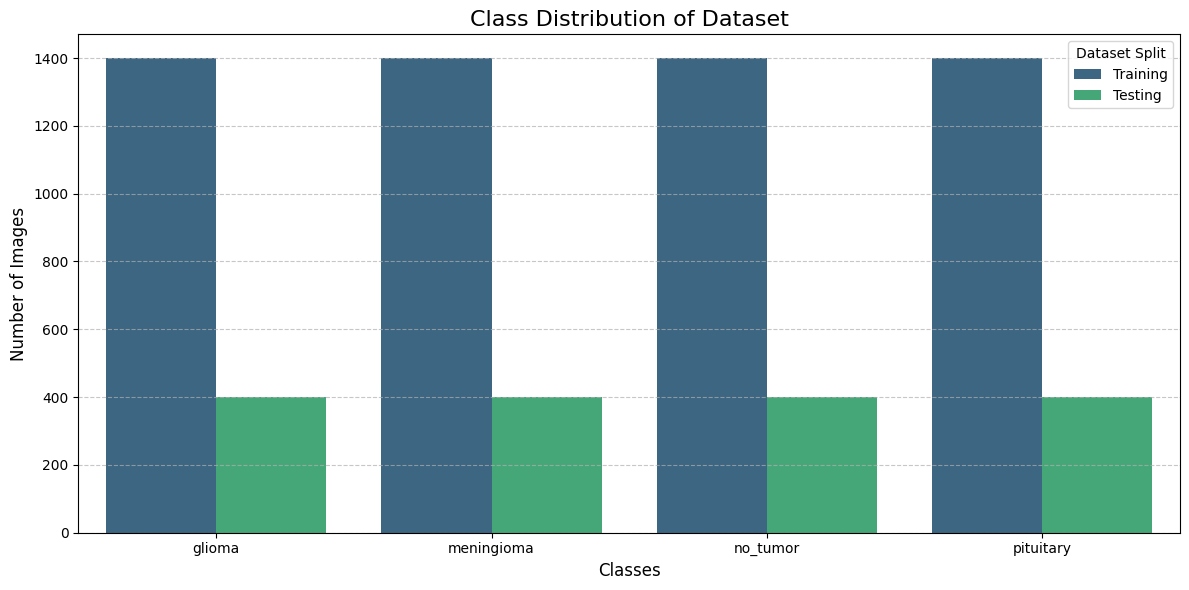

In [5]:
# Convert to DataFrame for easier plotting
df_counts = pd.DataFrame(class_counts).T.stack().reset_index()
df_counts.columns = ['Split', 'Classes', 'Count']

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Classes', y='Count', hue='Split', data=df_counts, palette='viridis')

# Add title, labels, and legend
plt.title('Class Distribution of Dataset', fontsize=16)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.legend(title='Dataset Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

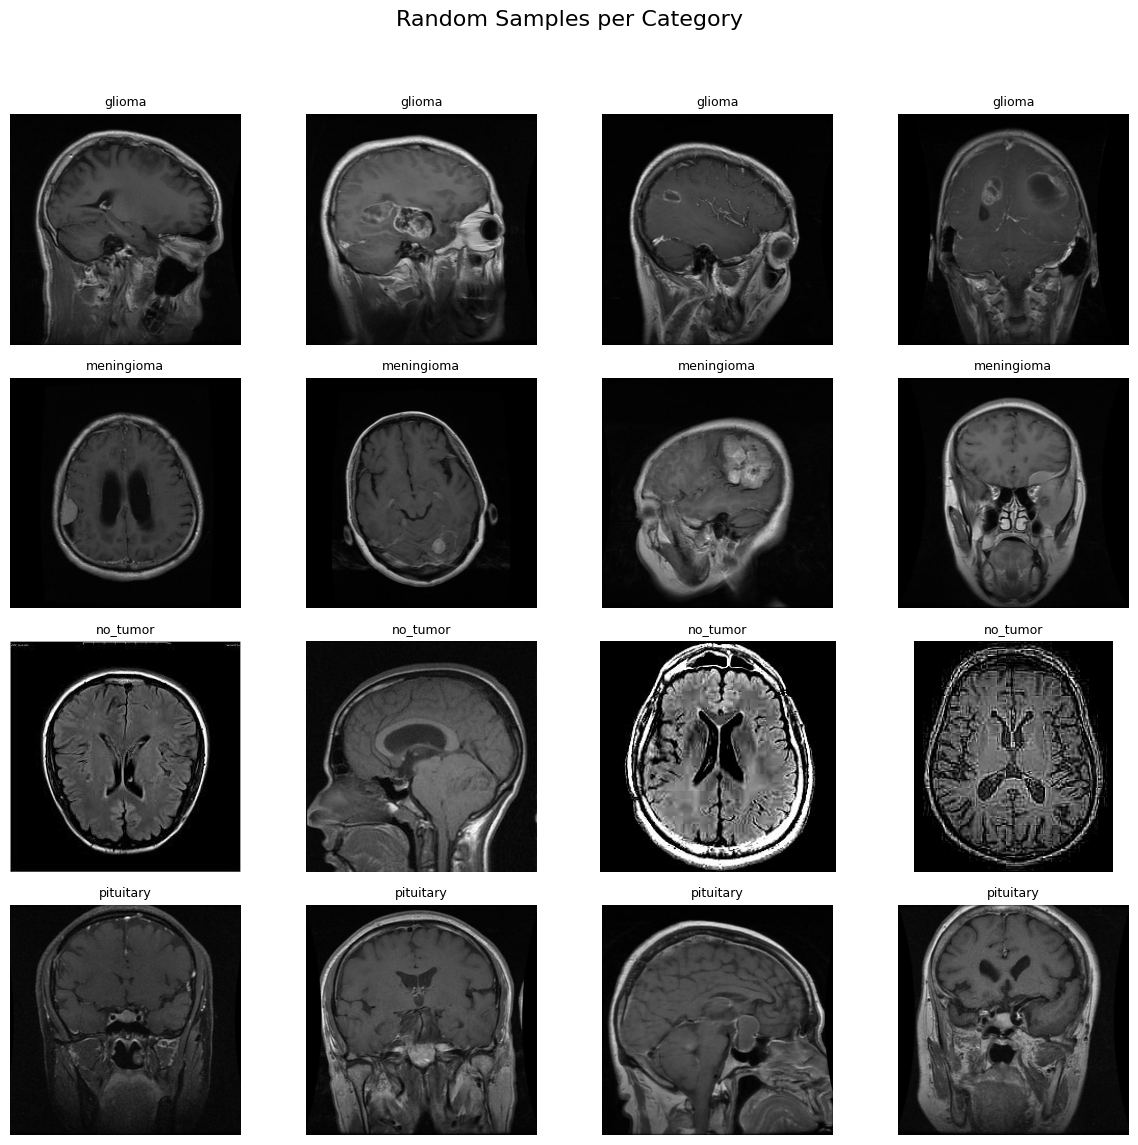

In [6]:
import random

sample_images = []
num_samples_per_category = 4

print("Collecting 4 random sample images per category...")
for category in CLASSES:
    category_path = os.path.join(BASE_DIR, 'Training', category)
    if os.path.exists(category_path):
        image_filenames = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if image_filenames:
            # Randomly select samples
            selected_samples = random.sample(image_filenames, min(num_samples_per_category, len(image_filenames)))
            for img_name in selected_samples:
                img_path = os.path.join(category_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    sample_images.append({'image': img_rgb, 'category': category})
        else:
            print(f"No images found in {category_path}")

# Create a grid layout
num_categories = len(CLASSES)
fig, axes = plt.subplots(num_categories, num_samples_per_category, figsize=(num_samples_per_category * 3, num_categories * 3))

for i, sample in enumerate(sample_images):
    row = i // num_samples_per_category
    col = i % num_samples_per_category
    ax = axes[row, col]
    ax.imshow(sample['image'])
    ax.set_title(sample['category'], fontsize=9)
    ax.axis('off')

plt.suptitle('Random Samples per Category', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

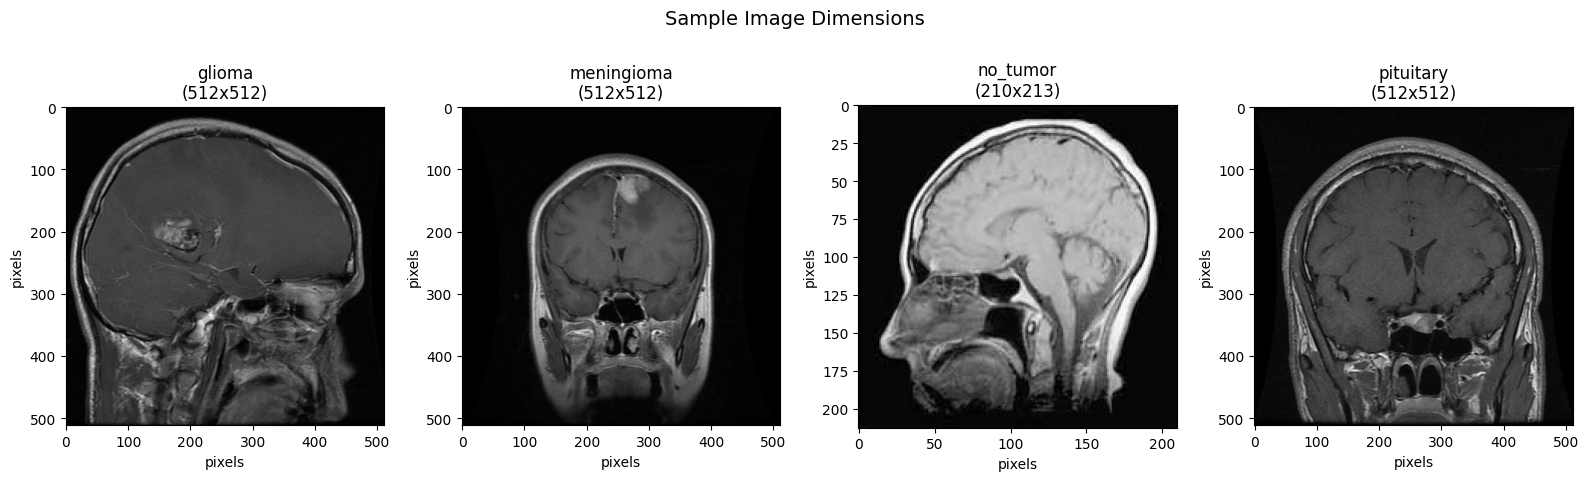

In [7]:
sample_images_info = []

for category in CLASSES:
    category_path = os.path.join(BASE_DIR, 'Training', category)
    if os.path.exists(category_path):
        image_filenames = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_filenames:
            img_path = os.path.join(category_path, image_filenames[0])
            img = cv2.imread(img_path)
            if img is not None:
                height, width, _ = img.shape
                sample_images_info.append({
                    'image': cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
                    'category': category,
                    'dimensions': f'{width}x{height}'
                })

if sample_images_info:
    fig, axes = plt.subplots(1, len(sample_images_info), figsize=(16, 5))
    for i, sample in enumerate(sample_images_info):
        ax = axes[i] if len(sample_images_info) > 1 else axes
        ax.imshow(sample['image'])
        ax.set_title(f"{sample['category']}\n({sample['dimensions']})")
        ax.set_xlabel('pixels')
        ax.set_ylabel('pixels')
    plt.suptitle('Sample Image Dimensions', fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Data Generators with Augmentation

**Note:** Grayscale images are converted to 3-channel RGB by repeating the grayscale channel.

In [8]:
def grayscale_to_rgb(img):
    if len(img.shape) == 2:
        img = tf.expand_dims(img, axis=-1)
    img = tf.image.grayscale_to_rgb(img)
    return img


def preprocess_image(image, label):
    image = tf.cast(image, tf.float32)
    return image, label


train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=0.15
)

val_datagen = ImageDataGenerator(
    validation_split=0.15
)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
    color_mode='rgb'
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42,
    color_mode='rgb'
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class indices: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Training samples: 4760
Validation samples: 840
Test samples: 1600


In [9]:
sample_batch = next(train_generator)
print(f"Batch shape: {sample_batch[0].shape}")
print(f"Batch labels shape: {sample_batch[1].shape}")

Batch shape: (32, 224, 224, 3)
Batch labels shape: (32, 4)


## 5. Build EfficientNetB0 Model

In [10]:
def build_model(num_classes):
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs, outputs)
    return model

model = build_model(NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,919 (16.83 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. Phase 1 - Train Classification Head

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('phase1_head_only.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("=" * 50)
print("PHASE 1: Training Classification Head")
print("=" * 50)

history_phase1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

PHASE 1: Training Classification Head
Epoch 1/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.6196 - loss: 0.8967
Epoch 1: val_accuracy improved from None to 0.85238, saving model to phase1_head_only.keras

Epoch 1: finished saving model to phase1_head_only.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.7338 - loss: 0.6730 - val_accuracy: 0.8524 - val_loss: 0.4130 - learning_rate: 0.0010
Epoch 2/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8248 - loss: 0.4735
Epoch 2: val_accuracy improved from 0.85238 to 0.86667, saving model to phase1_head_only.keras

Epoch 2: finished saving model to phase1_head_only.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 486ms/step - accuracy: 0.8202 - loss: 0.4693 - val_accuracy: 0.8667 - val_loss: 0.3789 - learning_rate: 0.0010
Epoch 3/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8483 - loss: 0.3945
Epoch 3: val_accuracy did not improve from 0.86667
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 480ms/step - accuracy: 0.

## 7. Phase 2 - Fine-Tuning (Unfreeze Top Layers)

In [12]:
model.load_weights('phase1_head_only.keras')

base_model = model.layers[1]
base_model.trainable = True

FINE_TUNE_LAYERS = 30

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    layer.trainable = True

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
frozen_count = sum([1 for layer in base_model.layers if not layer.trainable])
print(f"Trainable layers: {trainable_count}")
print(f"Frozen layers: {frozen_count}")

Trainable layers: 30
Frozen layers: 208


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('phase2_fine_tuned.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("=" * 50)
print("PHASE 2: Fine-Tuning (Unfrozen Top Layers)")
print("=" * 50)

history_phase2 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=fine_tune_callbacks,
    verbose=1
)

PHASE 2: Fine-Tuning (Unfrozen Top Layers)
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.7912 - loss: 0.6332
Epoch 1: val_accuracy improved from None to 0.88810, saving model to phase2_fine_tuned.keras

Epoch 1: finished saving model to phase2_fine_tuned.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.8088 - loss: 0.5561 - val_accuracy: 0.8881 - val_loss: 0.3251 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8488 - loss: 0.4302
Epoch 2: val_accuracy did not improve from 0.88810
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 482ms/step - accuracy: 0.8483 - loss: 0.4176 - val_accuracy: 0.8869 - val_loss: 0.3530 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8561 - loss: 0.3908
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy improved from 0.88810 to 0.89167, saving model to phase2_fine_tuned.keras

Epoch 3: finished savi

## 8. Training History Visualization

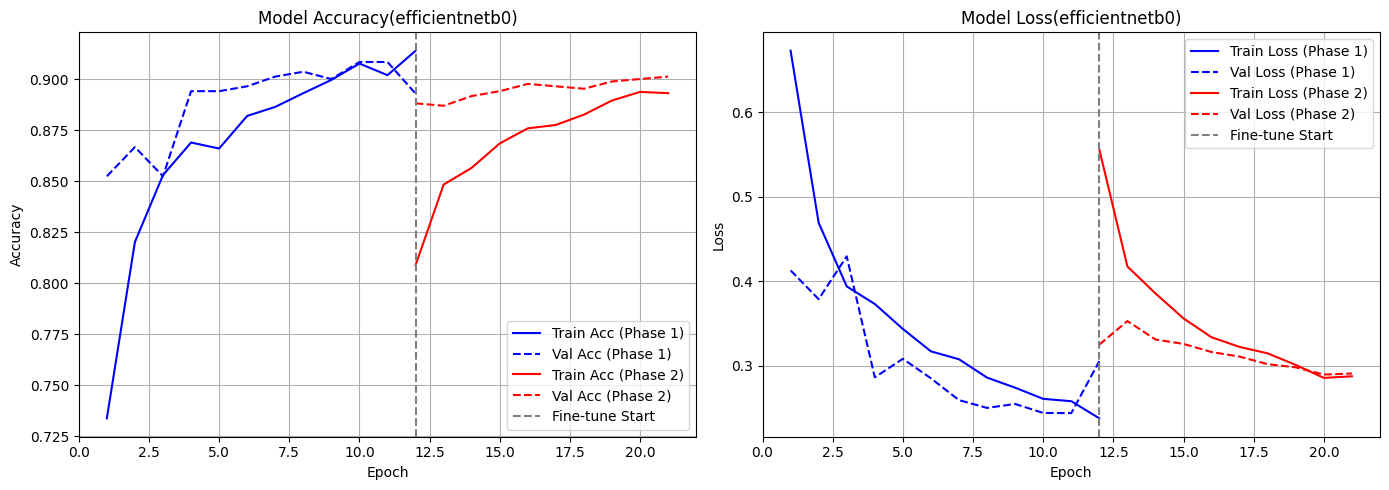

In [14]:
def plot_training_history(history_phase1, history_phase2):
    acc1 = history_phase1.history['accuracy']
    val_acc1 = history_phase1.history['val_accuracy']
    acc2 = history_phase2.history['accuracy']
    val_acc2 = history_phase2.history['val_accuracy']

    loss1 = history_phase1.history['loss']
    val_loss1 = history_phase1.history['val_loss']
    loss2 = history_phase2.history['loss']
    val_loss2 = history_phase2.history['val_loss']

    epochs_phase1 = len(acc1)
    epochs_phase2 = range(epochs_phase1, epochs_phase1 + len(acc2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, epochs_phase1 + 1), acc1, 'b-', label='Train Acc (Phase 1)')
    axes[0].plot(range(1, epochs_phase1 + 1), val_acc1, 'b--', label='Val Acc (Phase 1)')
    axes[0].plot(epochs_phase2, acc2, 'r-', label='Train Acc (Phase 2)')
    axes[0].plot(epochs_phase2, val_acc2, 'r--', label='Val Acc (Phase 2)')
    axes[0].axvline(x=epochs_phase1, color='gray', linestyle='--', label='Fine-tune Start')
    axes[0].set_title('Model Accuracy(efficientnetb0)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(range(1, epochs_phase1 + 1), loss1, 'b-', label='Train Loss (Phase 1)')
    axes[1].plot(range(1, epochs_phase1 + 1), val_loss1, 'b--', label='Val Loss (Phase 1)')
    axes[1].plot(epochs_phase2, loss2, 'r-', label='Train Loss (Phase 2)')
    axes[1].plot(epochs_phase2, val_loss2, 'r--', label='Val Loss (Phase 2)')
    axes[1].axvline(x=epochs_phase1, color='gray', linestyle='--', label='Fine-tune Start')
    axes[1].set_title('Model Loss(efficientnetb0)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_phase1, history_phase2)

## 9. Evaluation on Test Set

In [15]:
model.load_weights('phase2_fine_tuned.keras')

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n{'=' * 50}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'=' * 50}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8594 - loss: 0.5264

Test Accuracy: 85.94%
Test Loss: 0.5264


50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step


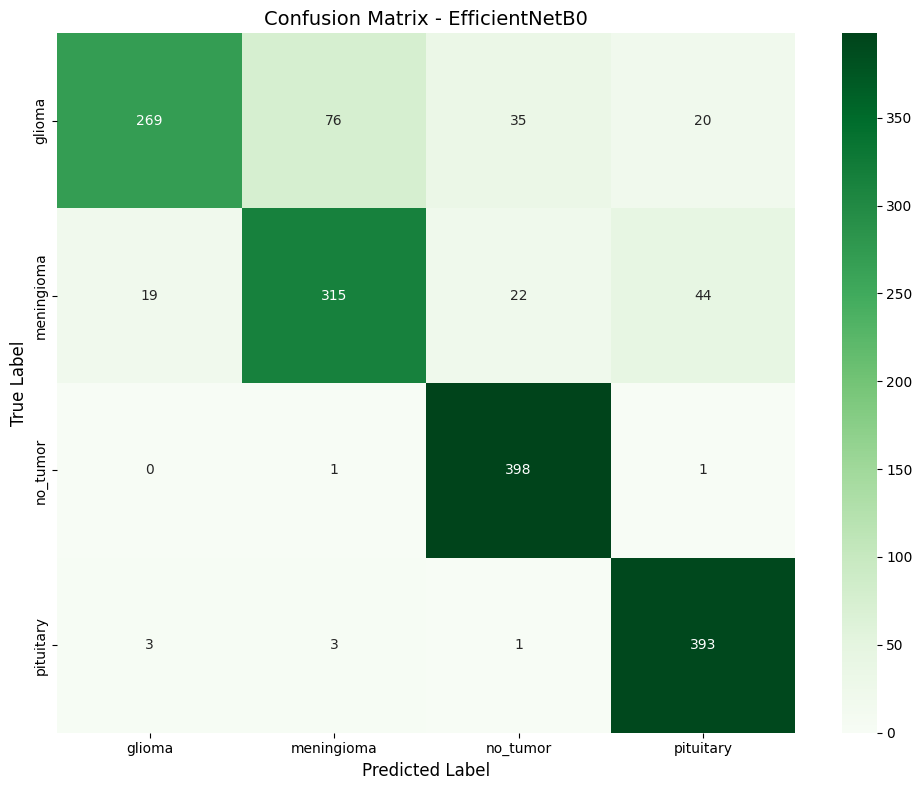


Classification Report(effnet):
              precision    recall  f1-score   support

      glioma     0.9244    0.6725    0.7786       400
  meningioma     0.7975    0.7875    0.7925       400
    no_tumor     0.8728    0.9950    0.9299       400
   pituitary     0.8581    0.9825    0.9161       400

    accuracy                         0.8594      1600
   macro avg     0.8632    0.8594    0.8543      1600
weighted avg     0.8632    0.8594    0.8543      1600



In [16]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - EfficientNetB0', fontsize=14)
plt.tight_layout()
plt.show()

print("\nClassification Report(effnet):")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

## 10. Save Full Model

In [17]:
model.save('brain_tumor_efficientnetb0.keras')
print("Full model saved: brain_tumor_efficientnetb0.keras")

Full model saved: brain_tumor_efficientnetb0.keras


## 11. Convert to TFLite

In [ ]:
def representative_data_generator():
    test_generator.reset()
    sample_count = 0
    for image_batch, _ in test_generator:
        for image in image_batch:
            yield [image[np.newaxis, ...].astype(np.float32)]
            sample_count += 1
            if sample_count >= 100:
                return


converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# For dynamic range quantization, representative_dataset is not needed.
# If full integer quantization is desired and this error persists, more complex debugging or different strategies may be required.
# converter.representative_dataset = representative_data_generator
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Re-enable select TF ops as they are required by the model
]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

tflite_path = 'brain_tumor_model2.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved: {tflite_path}")
print(f"Model size: {os.path.getsize(tflite_path) / (1024 * 1024):.2f} MB")

Saved artifact at '/tmp/tmpm_oe2kgh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_239')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135885253178384: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  135885253177424: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  135885364240144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135885364235536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135885364239184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135885364240720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135885364238032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135885364240528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135885364243792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135885364243984: TensorSpec(shape=(), dtype=tf.resource, name=

### 12. Download TFLite Model

In [ ]:
from google.colab import files
files.download('brain_tumor_model2.tflite')
files.download('brain_tumor_efficientnetb0.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>